# Regress trace element concentrations vs growth and environment

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [30]:
# Load necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import numpy as np
import statsmodels.api as sm

## Example: One specimen

In [31]:
# Load one file from the folder
file_path = "TE_data_with_GR_T_S/G652_sub_peakid.csv"  # Test for one specimen
data = pd.read_csv(file_path)
data.head()

,depth,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,55Mn/43Ca,88Sr/43Ca,...,timing_info_centered,interval_growth_rate,interval_growth_rate_centered,interval_total_growth,interval_total_growth_centered,interval_total_time_days,T,T_std,S,S_std
0,0.426825,0.131868,62.87978,71074.74930,46513.67210,1650.108907,831.612523,6.181713,2.065418,0.131868,...,2022-10-25 10:00:00,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
1,0.853650,0.108273,62.98893,71074.59489,46513.27419,1850.136910,694.830082,8.459364,1.591473,0.108273,...,2022-10-25 09:30:29.401482430,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
2,1.280475,0.000000,63.09807,71074.44047,46512.87627,1500.090005,1055.629092,12.315843,2.279010,0.000000,...,2022-10-25 09:00:58.802964860,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
3,1.707300,0.139467,63.20722,71074.28606,46512.47836,1600.102407,936.795248,32.690322,2.117207,0.139467,...,2022-10-25 08:31:28.204447290,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
4,2.134126,0.065934,63.31641,71074.13164,46512.08044,1650.108907,889.753685,18.545361,2.128978,0.065934,...,2022-10-25 08:01:57.601781419,19.748685,31.612585,914.713074,1464.221264,46.317669,5.872,0.025,25.39,0.073


### Plot Sr/Ca vs temperature

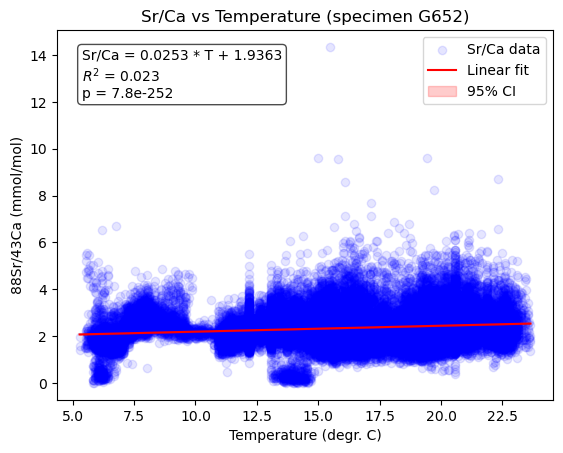

In [32]:
# Convert 'T' and 'T_std' columns to numeric, coerce errors to NaN
data['T'] = pd.to_numeric(data['T'], errors='coerce')
data['T_std'] = pd.to_numeric(data['T_std'], errors='coerce')

# Regression of Sr/Ca vs Temperature
# Remove rows with NaN in relevant columns
mask_temp = data[['T', '88Sr/43Ca']].notnull().all(axis=1)
x_temp = data.loc[mask_temp, 'T']
y_temp = data.loc[mask_temp, '88Sr/43Ca']

# Linear regression
slope_temp, intercept_temp, r_value_temp, p_value_temp, std_err_temp = linregress(x_temp, y_temp)
x_fit_temp = np.linspace(x_temp.min(), x_temp.max(), 200)
y_fit_temp = intercept_temp + slope_temp * x_fit_temp

# Calculate uncertainty envelope (95% confidence interval)
y_pred_temp = intercept_temp + slope_temp * x_temp
n_temp = len(x_temp)
t_val_temp = 1.96  # Approximate for large n, 95% CI
s_err_temp = np.sqrt(np.sum((y_temp - y_pred_temp) ** 2) / (n_temp - 2))
conf_temp = t_val_temp * s_err_temp * np.sqrt(1/n_temp + (x_fit_temp - np.mean(x_temp))**2 / np.sum((x_temp - np.mean(x_temp))**2))

# Plot Sr/Ca vs Temperature with uncertainties and regression fit in the same plot
plt.scatter(x_temp, y_temp, color='blue', alpha=0.1, label='Sr/Ca data')
plt.plot(x_fit_temp, y_fit_temp, color='red', label='Linear fit')
plt.fill_between(x_fit_temp, y_fit_temp - conf_temp, y_fit_temp + conf_temp, color='red', alpha=0.2, label='95% CI')
plt.xlabel('Temperature (degr. C)')
plt.ylabel('88Sr/43Ca (mmol/mol)')
plt.title('Sr/Ca vs Temperature (specimen G652)')

# Add regression statistics to the plot
eqn = f'Sr/Ca = {slope_temp:.4f} * T + {intercept_temp:.4f}'
stats = f'$R^2$ = {r_value_temp**2:.3f}\np = {p_value_temp:.1e}'
plt.text(0.05, 0.95, eqn + '\n' + stats, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.legend()
plt.show()

### Plot Sr/Ca vs growth rate

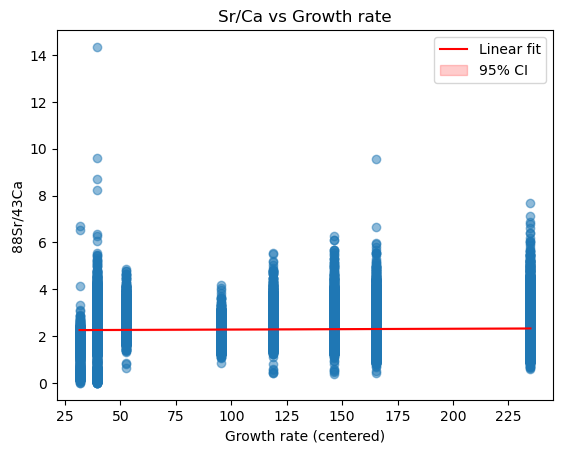

In [33]:
# Remove rows with NaN in relevant columns
mask = data[['interval_growth_rate_centered', '88Sr/43Ca']].notnull().all(axis=1)
x = data.loc[mask, 'interval_growth_rate_centered']
y = data.loc[mask, '88Sr/43Ca']

# Scatter plot
plt.plot(x, y, 'o', alpha=0.5)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = intercept + slope * x_fit

# Calculate uncertainty envelope (95% confidence interval)
y_pred = intercept + slope * x
n = len(x)
t_val = 1.96  # Approximate for large n, 95% CI
s_err = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))
conf = t_val * s_err * np.sqrt(1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

plt.plot(x_fit, y_fit, color='red', label='Linear fit')
plt.fill_between(x_fit, y_fit - conf, y_fit + conf, color='red', alpha=0.2, label='95% CI')

plt.xlabel('Growth rate (centered)')
plt.ylabel('88Sr/43Ca')
plt.title('Sr/Ca vs Growth rate')
plt.legend()
plt.show()

## Combine data from all specimens

### Read data from all specimens

In [34]:
# Load all files from the folder
folder_path = "TE_data_with_GR_T_S/"
all_data = pd.DataFrame()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        # Read each file
        file_data = pd.read_csv(
            os.path.join(folder_path, file),
            dtype={'T': "O", 'T_std': "O", 'S' : "O", 'S_std': "O"},
            index_col=0
        )
        # Add a column for the specimen name
        file_data['specimen'] = file.split('_')[0]  # Specimen name is the first part of the filename
        # Concatenate into a single DataFrame
        all_data = pd.concat([all_data, file_data], ignore_index=True)

# Display the first few rows of the combined data
all_data.head()

,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,43Ca/43Ca,55Mn/43Ca,88Sr/43Ca,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,0.013676,62.33211,30944.10620,80703.27530,6301.588000,199.059248,1.253571,1000.0,0.306491,0.013676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,62.44125,30944.46978,80703.01737,5301.123838,235.482235,3.406310,1000.0,0.347474,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.019326,62.55040,30944.83337,80702.75945,4600.846556,284.331679,1.771388,1000.0,0.380053,0.019326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.037763,62.65955,30945.19695,80702.50152,5751.322804,221.307763,3.115197,1000.0,0.348871,0.037763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.013795,62.76871,30945.56053,80702.24359,6251.562891,205.558351,1.264443,1000.0,0.242893,0.013795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clean combined dataframe

In [35]:
# Remove all unnamed columns
all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

# Convert temperature and salinity columns to numeric, coerce errors to NaN
all_data['T'] = pd.to_numeric(all_data['T'], errors='coerce')
all_data['T_std'] = pd.to_numeric(all_data['T_std'], errors='coerce')
all_data['S'] = pd.to_numeric(all_data['S'], errors='coerce')
all_data['S_std'] = pd.to_numeric(all_data['S_std'], errors='coerce')

# print dtypes of all columns
print(all_data.dtypes)

proxy_filtered                    float64
time                              float64
Xpos                              float64
Ypos                              float64
Ca43                              float64
23Na/43Ca                         float64
25Mg/43Ca                         float64
43Ca/43Ca                         float64
55Mn/43Ca                         float64
88Sr/43Ca                         float64
138Ba/43Ca                        float64
peak                               object
timing_info                        object
timing_info_centered               object
interval_growth_rate              float64
interval_growth_rate_centered     float64
interval_total_growth             float64
interval_total_growth_centered    float64
interval_total_time_days          float64
T                                 float64
T_std                             float64
S                                 float64
S_std                             float64
specimen                          

### Summarize elemental, growth and environmental values per specimen and per interval

In [36]:
# Summarize elemental, growth and environmental values per specimen and per interval, 
data_summary = all_data.groupby(['specimen', 'peak']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered', 'mean'),
    T_mean=('T', 'mean'),
    T_sd=('T', 'std'),
    S_mean=('S', 'mean'),
    S_std=('S', 'std'),
    N=('23Na/43Ca', 'count')
).reset_index()

# Display the first few rows of the summarized data
data_summary.head()

,specimen,peak,NaCa_mean,NaCa_sd,MgCa_mean,MgCa_sd,MnCa_mean,MnCa_sd,SrCa_mean,SrCa_sd,BaCa_mean,BaCa_sd,growth_mean,T_mean,T_sd,S_mean,S_std,N
0,B255,interval 0,44.567746,56.508452,1.160976,0.594605,0.034916,0.091594,1.158004,0.383664,0.001420,0.002077,21.405031,9.684376,2.533393,26.898304,1.767991,2143
1,B255,interval 1,26.273800,3.072668,0.719110,0.110520,0.006407,0.001172,1.278613,0.176885,0.001153,0.000252,49.726902,12.460874,0.922967,29.399738,1.094747,1963
2,B255,interval 2,25.151038,4.199140,0.962705,0.172410,0.010096,0.001694,1.889094,0.367165,0.002411,0.000558,149.865296,15.499778,1.119769,30.428576,0.485214,5226
3,B255,interval 3,23.462455,4.528163,0.967798,0.209171,0.010317,0.001871,2.038598,0.481682,0.003512,0.000961,179.218754,17.332671,1.919938,29.540670,0.748321,9455
4,B255,interval 4,22.258818,5.393297,1.157388,0.289976,0.008324,0.001733,2.167418,0.592524,0.005096,0.001246,89.825457,19.583781,0.389001,30.005489,0.691253,4311


### Export data summary

In [37]:
data_summary.to_csv("All_data_summary.csv", index=False)

## Linear regression models

### Linear regressions of all elements based on summary data

In [38]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean']

# Initialize an empty list
results_list_summarized = []

for element in outcome_vars:
    # Prepare the data for regression
    X = data_summary[predictors].dropna()
    y = data_summary[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Inside your loop
    results_list_summarized.append({
        'Element': element,
        'GR_slope': model.params.iloc[1],
        'T_slope': model.params.iloc[2],
        'S_slope': model.params.iloc[3],
        'GR_slope_norm': model.params['growth_mean'] / y.mean(),
        'T_slope_norm': model.params['T_mean'] / y.mean(),
        'S_slope_norm': model.params['S_mean'] / y.mean(),
        'Intercept': model.params.iloc[0],
        'R_squared': model.rsquared,
        'P_value': model.pvalues.iloc[1],
        'Std_err': model.bse.iloc[1],
        'RSE': model.bse.iloc[1] / y.mean(),
    })

# After the loop, create DataFrame
regression_results_summarized = pd.DataFrame(results_list_summarized)

# Display the regression results
print(regression_results_summarized)

     Element  GR_slope    T_slope    S_slope  GR_slope_norm  T_slope_norm  \
0  NaCa_mean -0.031281 -18.793518  19.982320      -0.000501     -0.301112   
1  MgCa_mean  0.003297  -0.786180   1.013509       0.001429     -0.340679   
2  MnCa_mean -0.000018  -0.048726   0.052615      -0.000170     -0.463532   
3  SrCa_mean  0.001141   0.041615   0.038447       0.000578      0.021083   
4  BaCa_mean  0.000027  -0.002574   0.003706       0.004138     -0.394532   

   S_slope_norm   Intercept  R_squared   P_value   Std_err       RSE  
0      0.320159 -250.474304   0.106927  0.884970  0.215848  0.003458  
1      0.439188  -16.438454   0.098572  0.679999  0.007978  0.003457  
2      0.500530   -0.735380   0.098123  0.975095  0.000571  0.005434  
3      0.019479    0.123054   0.409549  0.015164  0.000464  0.000235  
4      0.567944   -0.067708   0.081763  0.288076  0.000025  0.003881  


### Plot effect sizes of predictors

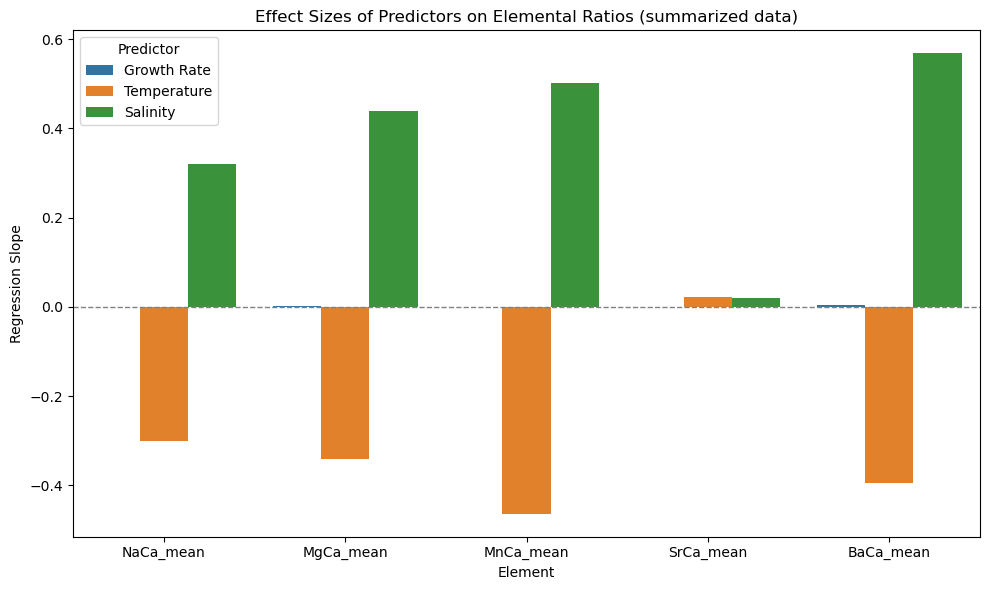

In [39]:
# Reshape the regression results to long format
effect_sizes_summarized = regression_results_summarized.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Optional: rename predictors for clarity
effect_sizes_summarized['Predictor'] = effect_sizes_summarized['Predictor'].map({
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity'
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=effect_sizes_summarized, x='Element', y='EffectSize', hue='Predictor')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Effect Sizes of Predictors on Elemental Ratios (summarized data)')
plt.ylabel('Regression Slope')
plt.tight_layout()
plt.legend(title='Predictor')
plt.show()

### Linear regressions of all elements based on full data

In [40]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
predictors = ['interval_growth_rate_centered', 'T', 'S']

# Initialize an empty list
results_list_all = []

for element in outcome_vars:
    # Prepare the data for regression
    X = all_data[predictors].dropna()
    y = all_data[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Inside your loop
    results_list_all.append({
        'Element': element,
        'GR_slope': model.params.iloc[1],
        'T_slope': model.params.iloc[2],
        'S_slope': model.params.iloc[3],
        'GR_slope_norm': model.params.iloc[1] / y.mean(),
        'T_slope_norm': model.params.iloc[2] / y.mean(),
        'S_slope_norm': model.params.iloc[3] / y.mean(),
        'Intercept': model.params.iloc[0],
        'R_squared': model.rsquared,
        'P_value': model.pvalues.iloc[1],
        'Std_err': model.bse.iloc[1],
        'RSE': model.bse.iloc[1] / y.mean(),
    })

# After the loop, create DataFrame
regression_results_all = pd.DataFrame(results_list_all)

# Display the regression results
print(regression_results_all)

      Element  GR_slope   T_slope   S_slope  GR_slope_norm  T_slope_norm  \
0   23Na/43Ca -0.042143 -2.821434  1.647005      -0.001228     -0.082241   
1   25Mg/43Ca -0.000582 -0.061751  0.096011      -0.000402     -0.042615   
2   55Mn/43Ca -0.000096 -0.007041  0.003993      -0.002699     -0.198354   
3   88Sr/43Ca  0.000947  0.021752  0.037637       0.000446      0.010247   
4  138Ba/43Ca  0.000006 -0.000119  0.000357       0.001366     -0.025207   

   S_slope_norm  Intercept  R_squared        P_value       Std_err       RSE  
0      0.048008  36.680580   0.018105  5.830148e-147  1.631911e-03  0.000048  
1      0.066259  -0.346222   0.002688   1.242167e-13  7.849261e-05  0.000054  
2      0.112499   0.043630   0.016030  9.256620e-113  4.244783e-06  0.000120  
3      0.017730   0.507487   0.095510   0.000000e+00  1.067483e-05  0.000005  
4      0.075566  -0.004951   0.001630   4.290816e-98  3.072822e-07  0.000065  


### Plot effect sizes of predictors

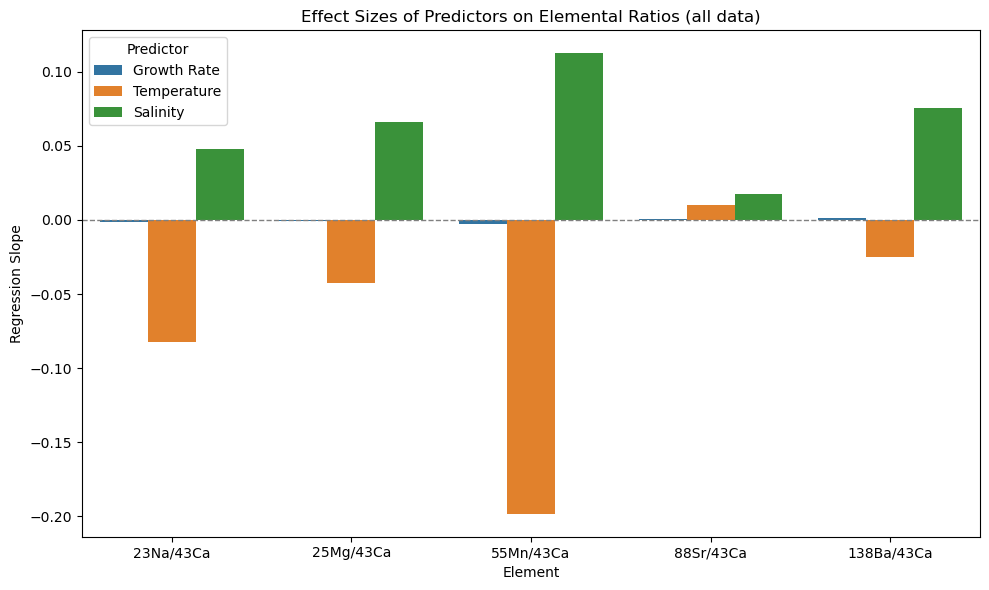

In [41]:
# Reshape the regression results to long format
effect_sizes_all = regression_results_all.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Optional: rename predictors for clarity
effect_sizes_all['Predictor'] = effect_sizes_all['Predictor'].map({
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity'
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=effect_sizes_all, x='Element', y='EffectSize', hue='Predictor')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Effect Sizes of Predictors on Elemental Ratios (all data)')
plt.ylabel('Regression Slope')
plt.tight_layout()
plt.legend(title='Predictor')
plt.show()